# Ground truth processing notebook

**Description**

This notebook is used for reclassifying ground truth data for deep learning model in later step. This public green space (PUGS) ground truth is from [European Urban Atlas (EUA)](https://land.copernicus.eu/en/products/urban-atlas/urban-atlas-2018).

Reclassify the LULC to two classes: public urban green spaces (PUGS) and non-public urban green spaces
- *Green urban areas* and *Forests* are classified as PUGS

**Input files**

1 geopackage file
- DE009L2_DRESDEN_UA2018_v013.gpkg

**Output files**

1 geojson file
- dresden_pugs_gt.geojson

**Requirements/Dependencies**

This notebook doesn't have dependency with other notebooks.

# Import libraries

In [1]:
import geopandas as gpd
import os
import rasterio
from rasterio import features
import numpy as np
import matplotlib.pyplot as plt

# Import data

In [9]:
dresden_eua_gpd = gpd.read_file('../data/raw/ground truth/DE009L2_DRESDEN_UA2018_v013.gpkg', layer='DE009L2_DRESDEN_UA2018')
dresden_boundary = gpd.read_file("../data/raw/boundary/dresden_boundary.geojson")

In [10]:
dresden_eua_gpd = dresden_eua_gpd.to_crs(epsg=4326)
dresden_boundary = dresden_boundary.to_crs(epsg=4326)

In [13]:
clipped_eua_dataset = gpd.clip(dresden_eua_gpd, dresden_boundary)

<Axes: >

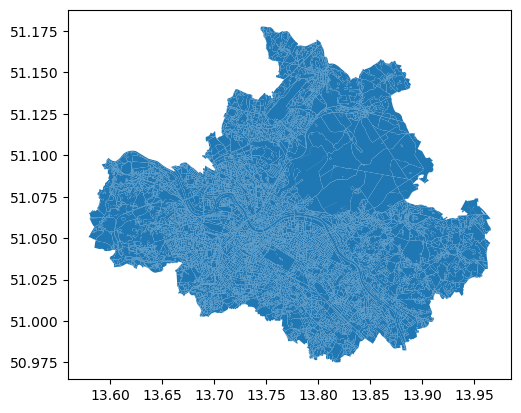

In [14]:
clipped_eua_dataset.plot()

## Reclassify EUA

In [15]:
clipped_eua_dataset['class_2018'].unique()

array(['Forests', 'Discontinuous dense urban fabric (S.L. : 50% -  80%)',
       'Industrial, commercial, public, military and private units',
       'Fast transit roads and associated land',
       'Permanent crops (vineyards, fruit trees, olive groves)',
       'Isolated structures', 'Pastures',
       'Discontinuous medium density urban fabric (S.L. : 30% - 50%)',
       'Arable land (annual crops)', 'Mineral extraction and dump sites',
       'Herbaceous vegetation associations (natural grassland, moors...)',
       'Green urban areas', 'Sports and leisure facilities',
       'Continuous urban fabric (S.L. : > 80%)', 'Water',
       'Discontinuous low density urban fabric (S.L. : 10% - 30%)',
       'Other roads and associated land',
       'Discontinuous very low density urban fabric (S.L. : < 10%)',
       'Land without current use', 'Railways and associated land',
       'Port areas', 'Construction sites', 'Airports'], dtype=object)

In [16]:
pugs_class_list = ['Green urban areas', 'Forests', 'Herbaceous vegetation associations (natural grassland, moors...)']

In [17]:
clipped_eua_dataset['new_class'] = 0
clipped_eua_dataset.loc[clipped_eua_dataset['class_2018'].isin(pugs_class_list), 'new_class'] = 1

In [18]:
clipped_eua_dataset.head()

,country,fua_name,fua_code,code_2018,class_2018,prod_date,identifier,perimeter,area,comment,Pop2018,geometry,new_class
60948,DE,Dresden,DE009L2,31000,Forests,2020-09,61166-DE009L2,8594.180156,755622.324881,None,0,"MULTIPOLYGON (((13.7991 50.9777, 13.79909 50.9...",1
26186,DE,Dresden,DE009L2,11210,Discontinuous dense urban fabric (S.L. : 50% -...,2020-09,8563-DE009L2,470.740149,11549.482881,None,32,"POLYGON ((13.79405 50.97803, 13.7938 50.97796,...",0
26527,DE,Dresden,DE009L2,12100,"Industrial, commercial, public, military and p...",2020-09,27413-DE009L2,426.572356,7374.405198,None,2,"POLYGON ((13.87359 50.98337, 13.87393 50.98332...",0
26187,DE,Dresden,DE009L2,12210,Fast transit roads and associated land,2020-09,34385-DE009L2,3421.920301,64748.075298,None,0,"POLYGON ((13.8075 50.97729, 13.80764 50.97732,...",0
49092,DE,Dresden,DE009L2,22000,"Permanent crops (vineyards, fruit trees, olive...",2020-09,49346-DE009L2,1392.923801,38805.161496,None,12,"MULTIPOLYGON (((13.81012 50.97705, 13.81015 50...",0


In [19]:
cropped_data = clipped_eua_dataset.to_crs(epsg=32633)

In [20]:
try:
   os.makedirs("../data/processed/ground truth")
except FileExistsError:
   # Directory already exists
   pass

# Save the cropped data
cropped_data[cropped_data['new_class'] == 1].to_file('../data/processed/ground truth/dresden_pugs_gt.geojson', driver='GeoJSON')

# Rasterize ground truth

Pixel width: 10.0 meters
Pixel height: 10.0 meters


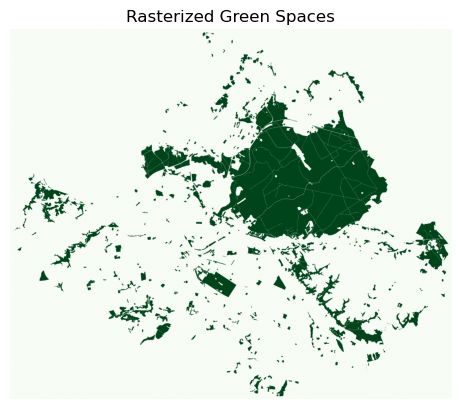

Saved rasterized mask to ../data/processed/ground truth/dresden_pugs_gt.geotiff


In [21]:
image_path = '../data/processed/sentinel-2/stacked_sentinel2_dresden.geotiff'

with rasterio.open(image_path) as src:
    # Copy metadata from sentinel-2 image
    transform = src.transform
    width = src.width
    height = src.height
    crs = src.crs

    # Extract and print pixel dimensions
    pixel_width = transform[0]  # x resolution
    pixel_height = abs(transform[4])  # y resolution (absolute value as it's negative)
    
    print(f"Pixel width: {pixel_width} meters")
    print(f"Pixel height: {pixel_height} meters")

    # Create empty raster
    mask = np.zeros((height, width), dtype=np.uint8)
    
    # Rasterize the vector data
    shapes = [(geom, 1) for geom in cropped_data[cropped_data['new_class'] == 1].geometry]
    
    # Burn vector features into raster
    burned = features.rasterize(
        shapes=shapes,
        out=mask,
        transform=transform,
        fill=0,
        dtype=np.uint8
    )
    
    plt.imshow(burned, cmap='Greens')
    plt.title('Rasterized Green Spaces')
    plt.axis('off')
    plt.show()
    
    # Save the rasterized data
    output_path = '../data/processed/ground truth/dresden_pugs_gt.geotiff'
    
    with rasterio.open(
        output_path,
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype=np.uint8,
        crs=crs,
        transform=transform
    ) as dst:
        dst.write(burned, 1)
    
    print(f"Saved rasterized mask to {output_path}")